In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

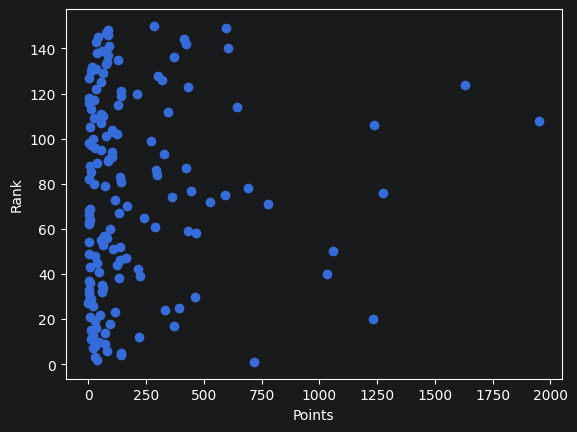

In [3]:
import pandas as pd

df = pd.read_csv("hn_stories.csv")

plt.scatter(df['points'], df['rank'])
plt.xlabel("Points")
plt.ylabel("Rank")
plt.show()

In [6]:
##---------------LINEAR SINGULAR
from sklearn.linear_model import LinearRegression

x = df[['points']]
y = df['rank']

modelA = LinearRegression()
modelA.fit(x, y)

print("Coefficient:", modelA.coef_)
print("Intercept:", modelA.intercept_)
print("Score:", modelA.score(x, y))


Coefficient: [0.01165551]
Intercept: 73.17752211487279
Score: 0.007047144228817248


In [8]:
##-----------------------LINEAR MULTIPLE
x = df[['points', 'comments', 'age_hours']]

modelB = LinearRegression()
modelB.fit(x, y)
print("Score:", modelB.score(x, y))

Score: 0.4015780537702811


In [12]:
##-------------------AGE INVERSE
df['age_inv'] = 1 / (df['age_hours'] + 0.01)
x = df[['points', 'comments', 'age_inv']]

modelC = LinearRegression()
modelC.fit(x, y)
print("Score:", modelC.score(x, y))


Score: 0.17360595837750015


/Users/demih/School/MSD_CS6017/Homework/Homework03/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


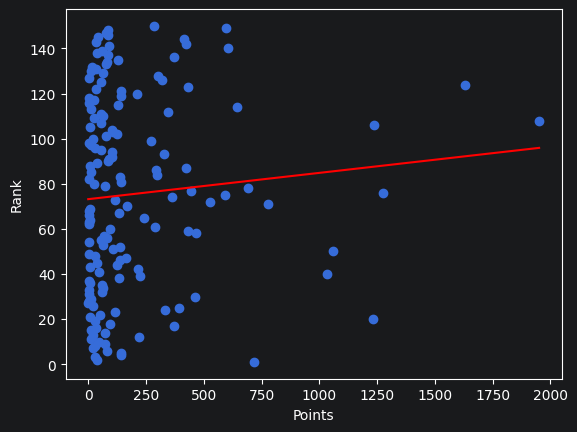

In [11]:
##-----------------------------CHART
import pandas as pd
import numpy as np

plt.scatter(df['points'], df['rank'])
x = np.linspace(df['points'].min(), df['points'].max(), 100).reshape(-1, 1)

plt.plot(x, modelA.predict(x), color='red')
plt.xlabel("Points")
plt.ylabel("Rank")
plt.show()


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df['front_page'] = (df['rank'] <= 10).astype(int)

x = df[['points', 'comments', 'age_hours', 'title_length']]
y = df['front_page']

xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.2, random_state=42)

log = LogisticRegression(max_iter=1000)
log.fit(xTrain, yTrain)

predictor = log.predict(xTest)

print("Accuracy:", accuracy_score(yTest, predictor))

Accuracy: 0.9666666666666667


In [ ]:
##ANALYSIS

##----------Regression 1
## I didn't find that using points as the only metric could predict rank. There are too many other factors that have an impact.

##-----------Regression 2
## In my opinion, adding  more factors into the analysis helped to better predict the results, because it allowed for a larger, more complete picture of what was truly happening by taking multiple facets into account at once.

##---------Regression 3
## While it's generally important to take a factor such as age into account, it's equally important how you address it. We measure time the same way throughout all the articles, but all those ages don't end up 'weighing' the same. For example, article A might be one hour older than article B; but whether that boils down to respective ages of 1 hour and 2 hours or 101 and 102 hours presents a very different meaning. For this reason, it's wise to address time in a nonlinear fashion.